In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Esercizio 9

In questo esercizio ho implementato un **algoritmo genetico** per risolvere il problema del commesso viaggiatore (TSP, Travelling Salesman Problem). L'obiettivo è trovare il percorso chiuso di lunghezza minima che permetta di visitare tutte le città una sola volta, tornando infine alla città di partenza.

Ho testato l'algoritmo su due diverse configurazioni geometriche delle città: una distribuzione uniforme su una **circonferenza** e una distribuzione uniforme all'interno di un **quadrato**. In entrambi i casi considero $34$ città, una popolazione di $500$ individui e $600$ generazioni.

### 1. Generazione delle città e della popolazione

Per il primo caso genero le città sulla circonferenza tramite la funzione `city_cerchio`, mentre per il secondo caso utilizzo `city_quadrato`, che genera le città all'interno di un quadrato.

Per entrambi i casi utilizzo

$$
N_{\mathrm{city}}=34,
\qquad
N_{\mathrm{pop}}=500,
\qquad
N_{\mathrm{gen}}=600.
$$

La popolazione iniziale viene costruita generando $500$ percorsi casuali tramite il costruttore della classe `Population`. Ogni individuo della popolazione è quindi rappresentato da un oggetto `Path`, che contiene l'ordine con cui vengono visitate le città.

### 2. Fitness

La fitness di ogni individuo è rappresentata dalla **lunghezza totale del percorso**. Per un percorso costituito dalle città

$$
c_0,c_1,\ldots,c_{N_{\mathrm{city}}-1},
$$

la lunghezza è data da

$$
L =
\sum_{i=0}^{N_{\mathrm{city}}-2}
d(c_i,c_{i+1})
+
d(c_{N_{\mathrm{city}}-1},c_0),
$$

dove l'ultimo termine tiene conto del ritorno alla città di partenza.

Poiché il problema consiste nel minimizzare la lunghezza, una fitness più bassa corrisponde a una soluzione migliore. Per questo motivo, ad ogni generazione ordino la popolazione in ordine crescente di lunghezza tramite `sort_by_fitness`.

Il primo individuo della popolazione rappresenta quindi il percorso migliore della generazione corrente.

### 3. Selezione

Per la selezione dei genitori utilizzo la funzione `select`, che introduce una preferenza verso gli individui con fitness migliore.

Viene estratto un numero casuale uniforme $x\in[0,1]$ e l'indice dell'individuo selezionato viene calcolato come

$$
i=\left\lfloor N_{\mathrm{pop}}x^p\right\rfloor,
$$

con

$$
p=2.
$$

Poiché per $0<x<1$ vale $x^2<x$, questo metodo aumenta la probabilità di selezionare gli individui che si trovano nelle prime posizioni della popolazione, cioè quelli con percorso più corto.

### 4. Crossover

Dopo aver selezionato due genitori, indicati come `M` e `F`, applico il crossover con probabilità

$$
P_{\mathrm{cross}}=0.7.
$$

Il crossover è implementato tramite la funzione `half_crossover`. Viene scelta casualmente una posizione di taglio e una parte del percorso del primo genitore viene copiata nel figlio.

Successivamente, il percorso viene completato utilizzando le città del secondo genitore nell'ordine in cui compaiono, inserendo solamente quelle che non sono già presenti nel figlio.

In questo modo il figlio contiene tutte le città una sola volta e rappresenta quindi un percorso valido.

Per ogni coppia di genitori genero due figli, invertendo il ruolo dei due genitori nel secondo crossover.

### 5. Mutazioni

Dopo il crossover applico due possibili operazioni di mutazione.

La prima è la mutazione di tipo **swap**, applicata con probabilità

$$
P_{\mathrm{swap}}=0.3.
$$

Questa operazione modifica il percorso scambiando tra loro due città.

La seconda è una mutazione di tipo **shift**, applicata con probabilità

$$
P_{\mathrm{shift}}=0.1.
$$

In questo caso viene effettuato uno spostamento ciclico di una parte del percorso.

Le mutazioni permettono di introdurre nuove configurazioni e aumentano la capacità dell'algoritmo di esplorare lo spazio delle possibili soluzioni, evitando che la popolazione converga troppo rapidamente verso una configurazione non ottimale.

Dopo le operazioni genetiche verifico inoltre che i figli siano percorsi validi tramite la funzione `check()`. Se un individuo non è valido, il programma segnala un errore e interrompe l'esecuzione.

### 6. Elitismo

Nella costruzione della nuova generazione mantengo sempre il miglior individuo della generazione precedente:

```cpp
new_pop.push_back(best());
```

Questo introduce una strategia di **elitismo**, poiché la soluzione migliore non può essere persa a causa del crossover o delle mutazioni.

I restanti individui vengono invece generati selezionando casualmente due genitori e applicando, con le probabilità stabilite, crossover e mutazioni.

### 7. Evoluzione della popolazione

L'evoluzione della popolazione viene quindi effettuata per $600$ generazioni. Ad ogni generazione:

1. ordino la popolazione in base alla fitness;
2. salvo la lunghezza del percorso migliore;
3. calcolo la lunghezza media della metà migliore della popolazione;
4. genero una nuova popolazione tramite selezione, crossover e mutazioni.

Oltre al miglior individuo, considero quindi anche la media della fitness del **50% migliore della popolazione**, calcolata tramite `average_best_half`.

Questo secondo parametro permette di seguire non solo l'evoluzione della soluzione migliore, ma anche quella dell'intera regione più performante della popolazione.


### 8. Percorso finale

Al termine delle $600$ generazioni estraggo il miglior individuo della popolazione.


### 9. Confronto tra circonferenza e quadrato

L'esercizio permette infine di confrontare il comportamento dell'algoritmo genetico in due geometrie differenti.

Nel caso della **circonferenza**, la soluzione ottimale dovrebbe seguire la struttura geometrica naturale della distribuzione delle città, mentre nel caso del **quadrato** il percorso ottimale deve tenere conto della distribuzione bidimensionale delle città all'interno della superficie.

Il confronto tra `fitness_circle.dat` e `fitness_square.dat` permette di analizzare la velocità di convergenza dell'algoritmo nei due casi, mentre i file `best_path_circle.dat` e `best_path_square.dat` permettono di visualizzare direttamente i percorsi finali trovati.


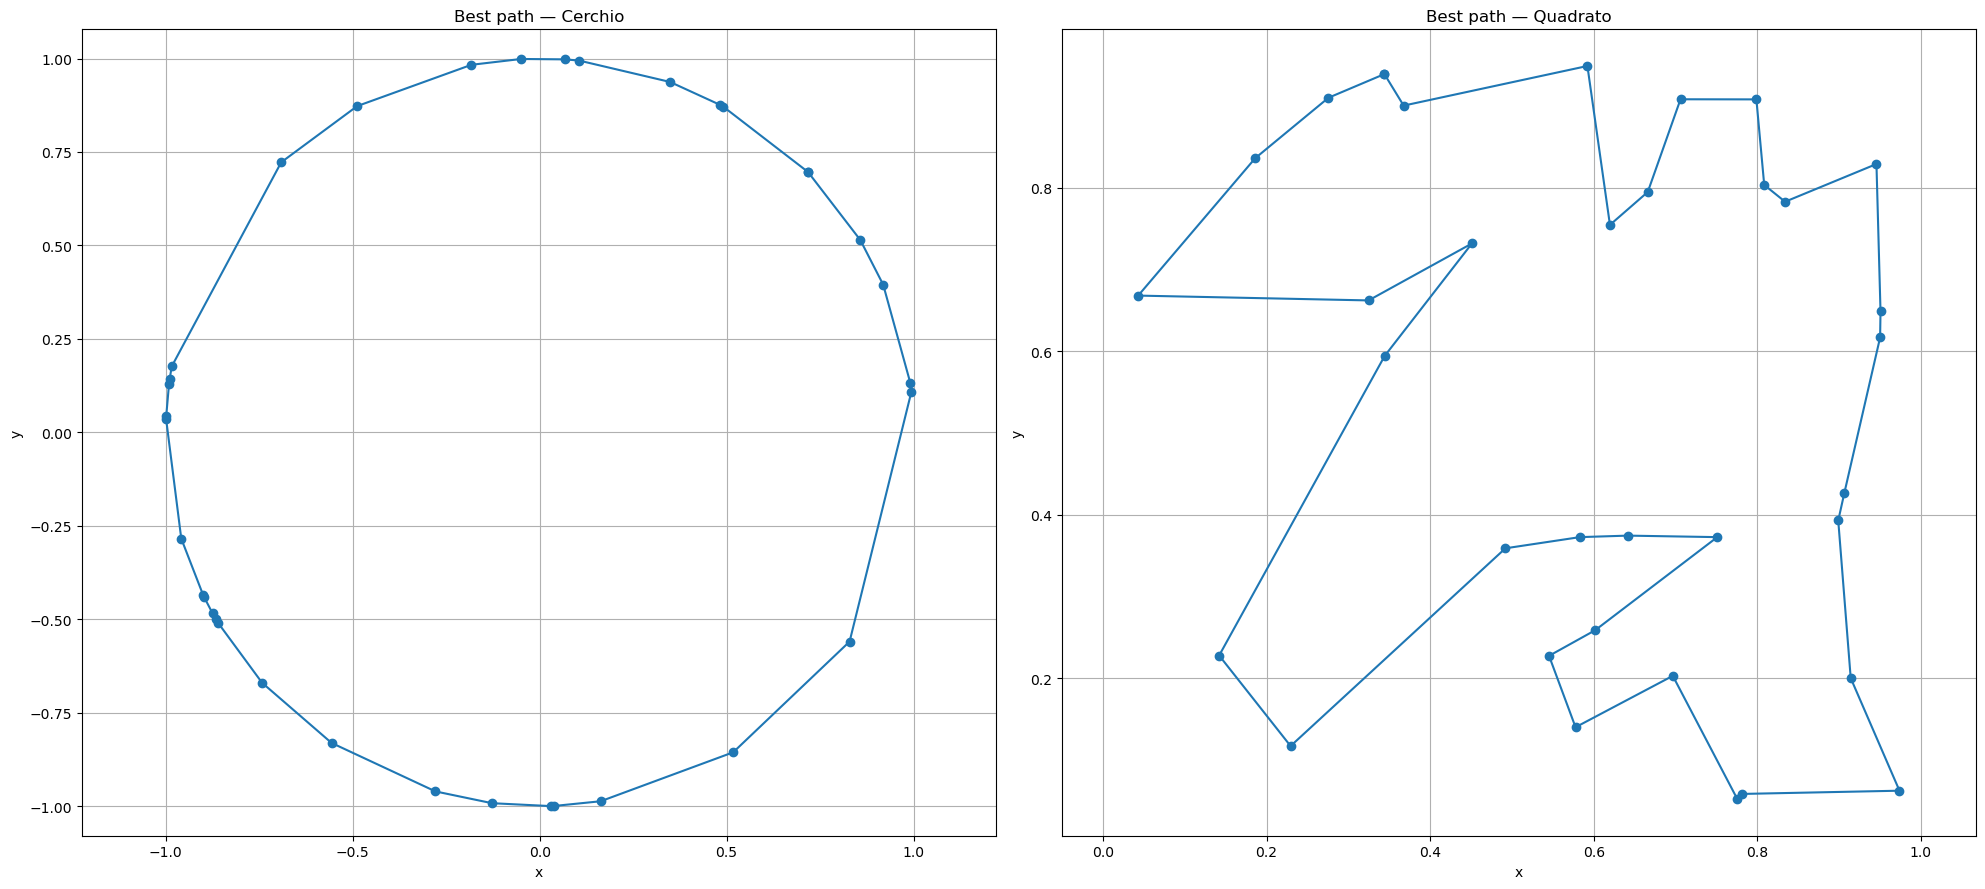

In [7]:
cities1 = np.loadtxt("best_path_circle.dat")
x1 = cities1[:,0]
y1 = cities1[:,1]

cities2 = np.loadtxt("best_path_square.dat")
x2 = cities2[:,0]
y2 = cities2[:,1]

plt.figure(figsize=(20, 9))

plt.subplot(1,2,1)
plt.plot(x1, y1, '-o')
plt.axis("equal")
plt.grid()
plt.title("Best path — Cerchio")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(1,2,2)
plt.plot(x2, y2, '-o')
plt.axis("equal")
plt.grid()
plt.title("Best path — Quadrato")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

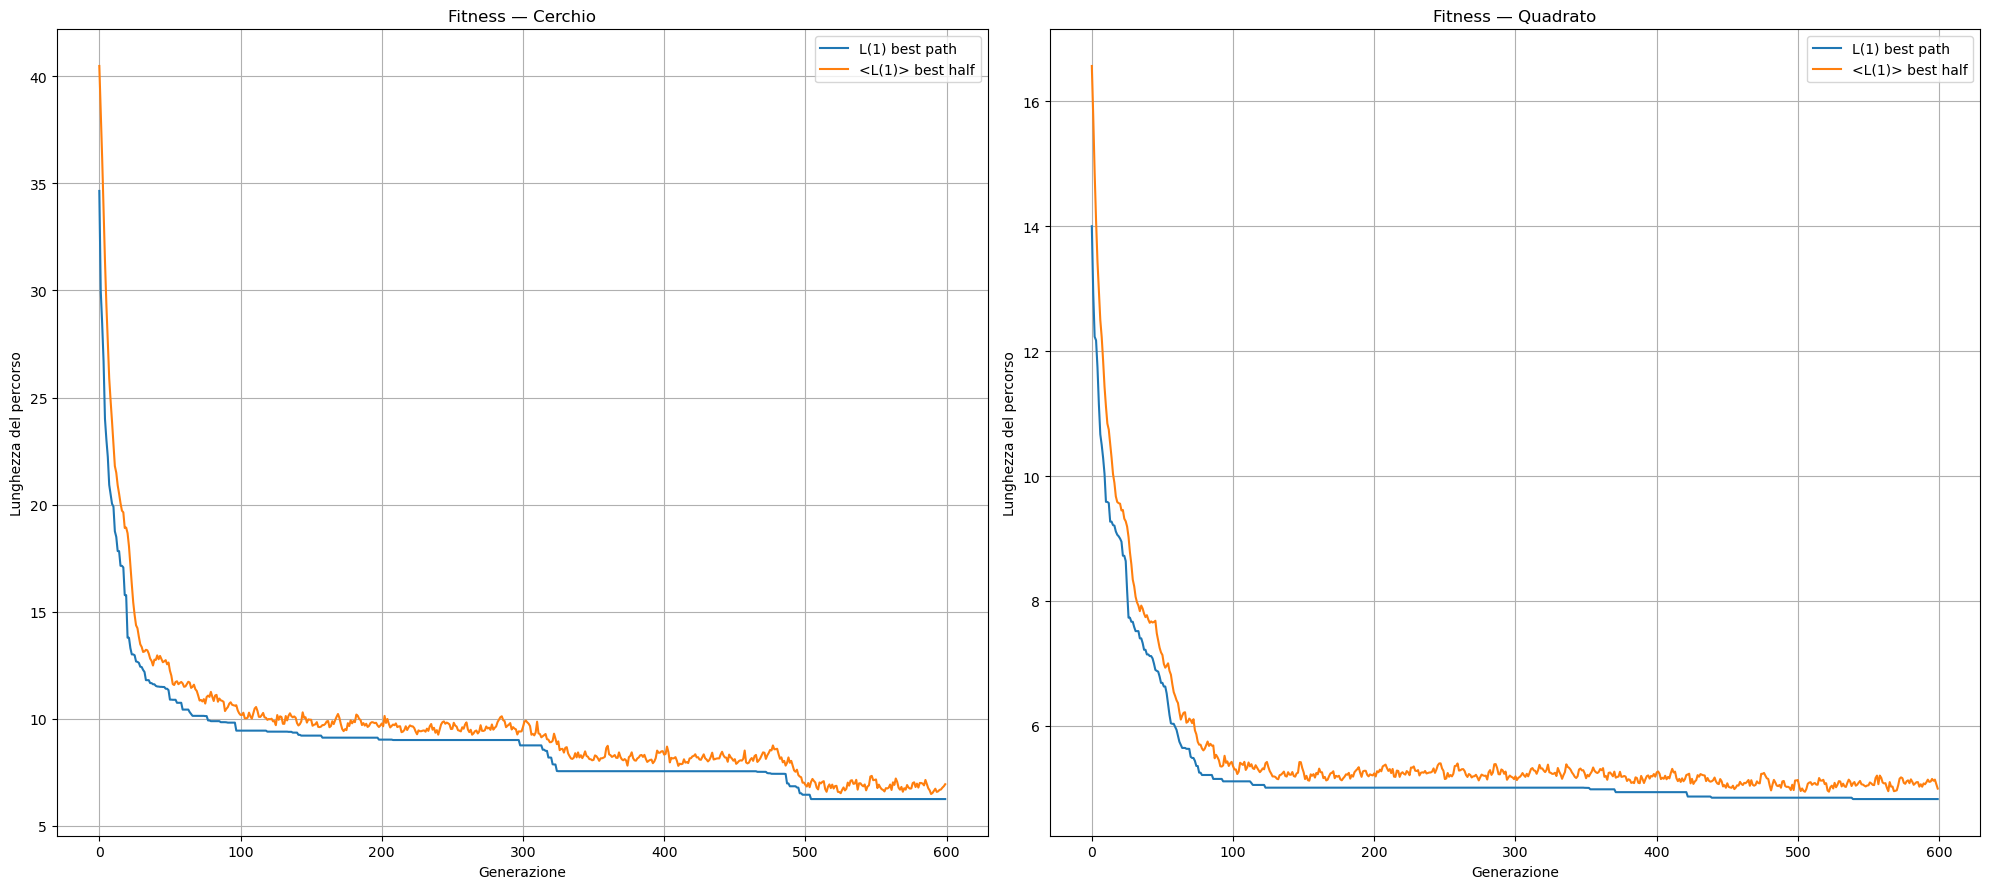

In [6]:
data1 = np.loadtxt("fitness_circle.dat")
gen1 = data1[:,0]
len1 = data1[:,1]
avg1 = data1[:,2]

data2 = np.loadtxt("fitness_square.dat")
gen2 = data2[:,0]
len2 = data2[:,1]
avg2 = data2[:,2]

plt.figure(figsize=(20,9))

plt.subplot(1,2,1)
plt.plot(gen1, len1, label="L(1) best path")
plt.plot(gen1, avg1, label="<L(1)> best half")
plt.xlabel("Generazione")
plt.ylabel("Lunghezza del percorso")
plt.title("Fitness — Cerchio")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(gen2, len2, label="L(1) best path")
plt.plot(gen2, avg2, label="<L(1)> best half")
plt.xlabel("Generazione")
plt.ylabel("Lunghezza del percorso")
plt.title("Fitness — Quadrato")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Commento

### Grafici della traiettoria

I due grafici che rappresentano la traiettoria del percorso individuato come ottimale evidenziano il buon funzionamento dell’algoritmo genetico. In entrambi i casi, il percorso ottenuto appare coerente con una soluzione di lunghezza minima.

Nel caso delle città disposte su una circonferenza, la lunghezza del percorso ottimale risulta molto vicina a quella della circonferenza unitaria. Anche nel caso delle città distribuite casualmente all’interno di un quadrato, nonostante la maggiore complessità della configurazione, il percorso individuato risulta verosimilmente ottimale.

In entrambi i casi vengono inoltre rispettati i vincoli del problema: ogni città viene visitata una sola volta e il percorso non presenta incroci.

### Grafici della lunghezza del percorso

Nei due grafici viene confrontata, per ogni generazione, la lunghezza del percorso migliore con la lunghezza media dei percorsi appartenenti alla metà migliore della popolazione. Si osserva che la curva blu, relativa al percorso migliore, si trova sempre al di sotto di quella arancione, relativa alla media della metà migliore. Questo comportamento è coerente con il corretto funzionamento dell’algoritmo.

Inoltre, la differenza relativamente contenuta tra le due curve indica che la popolazione non è costituita esclusivamente da un singolo percorso ottimale, ma contiene una classe di percorsi caratterizzati da lunghezze simili e prossime al valore minimo.

Infine, l’andamento a gradini delle due curve è coerente con il funzionamento dell’algoritmo genetico: la lunghezza del percorso migliore può diminuire solo quando viene individuata, in una determinata generazione, una soluzione migliore rispetto a quelle precedentemente trovate.
